In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Load significant pathways from Excel file
#df = pd.read_excel('bubble_plot_pathways.xlsx')
df = pd.read_excel('bubbles_decNeg.xlsx')

# Check column names and adjust if needed
print("Column names:", df.columns.tolist())

# If columns don't have headers or have different names, assign them
if len(df.columns) == 6:
    df.columns = ['Pathway', '%_Essential', 'RNA_log2FC', 'pvalue_RNA', 'Flux_log2FC', 'pvalue_flux']

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Filter out empty pathways
df = df[df['Pathway'].notna() & (df['Pathway'].str.strip() != '')]

# Convert to proper types
df['%_Essential'] = pd.to_numeric(df['%_Essential'], errors='coerce')
df['RNA_log2FC'] = pd.to_numeric(df['RNA_log2FC'], errors='coerce')
df['Flux_log2FC'] = pd.to_numeric(df['Flux_log2FC'], errors='coerce')
df['pvalue_RNA'] = pd.to_numeric(df['pvalue_RNA'], errors='coerce')
df['pvalue_flux'] = pd.to_numeric(df['pvalue_flux'], errors='coerce')

# Remove any rows with NaN values in critical columns
df = df.dropna(subset=['%_Essential', 'RNA_log2FC', 'Flux_log2FC', 'pvalue_RNA', 'pvalue_flux'])

# Define significance threshold
significance_threshold = 0.05

# Function to determine bubble color based on significance and direction
def get_bubble_color(log2fc, pvalue):
    if pvalue < significance_threshold:
        if log2fc > 0:
            return '#d62728'  # Red for significant increase
        else:
            return '#1f77b4'  # Blue for significant decrease
    else:
        return '#808080'  # Grey for not significant

# Add color columns for RNA and Flux
df['RNA_color'] = df.apply(lambda row: get_bubble_color(row['RNA_log2FC'], row['pvalue_RNA']), axis=1)
df['Flux_color'] = df.apply(lambda row: get_bubble_color(row['Flux_log2FC'], row['pvalue_flux']), axis=1)

# Sort pathways by RNA-seq log2 Fold Change (descending)
df = df.sort_values('RNA_log2FC', ascending=False)

# Extract variables
pathways = df['Pathway'].tolist()  # Convert to list
growth_percent = df['%_Essential'].values
rna_log2fc = df['RNA_log2FC'].values
flux_log2fc = df['Flux_log2FC'].values
rna_colors = df['RNA_color'].values
flux_colors = df['Flux_color'].values

# Debug print
print(f"Number of pathways: {len(pathways)}")
print(f"First few pathways: {pathways[:3] if len(pathways) > 0 else 'None'}")

# Bubble size scaling
bubble_scale = 5
bubble_sizes = growth_percent * bubble_scale

# Create figure with subplots - make it even wider for more legend space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# RNA-seq plot (left)
y_positions = list(range(len(pathways)))
scatter1 = ax1.scatter(rna_log2fc, y_positions, s=bubble_sizes,
                      c=rna_colors, edgecolor='k', linewidth=0.8, alpha=0.8)

# Model Flux plot (right)
scatter2 = ax2.scatter(flux_log2fc, y_positions, s=bubble_sizes,
                      c=flux_colors, edgecolor='k', linewidth=0.8, alpha=0.8)

# Add vertical dashed lines at x = 0
ax1.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Set up y-axis for both plots
ax1.set_ylim(-0.5, len(pathways) - 0.5)
ax2.set_ylim(-0.5, len(pathways) - 0.5)

# Set y-axis labels (only on left plot)
ax1.set_yticks(y_positions)
ax1.set_yticklabels(pathways, fontsize=14)
ax1.invert_yaxis()

# Right plot - no labels but same ticks
ax2.set_yticks(y_positions)
ax2.set_yticklabels([])
ax2.invert_yaxis()

# Make sure y-axis is visible on left plot
ax1.tick_params(axis='y', which='major', labelsize=14, length=4)
ax2.tick_params(axis='y', which='major', length=4)

# Debug: Print y-axis info
print(f"Y positions: {y_positions[:3]}")
print(f"Y labels set: {len(pathways)} labels")
print(f"Pathways: {pathways[:3] if pathways else 'No pathways'}")

# Axis labels
ax1.set_xlabel('RNA-seq log2 Fold Change\n(Drought vs Control)', fontsize=14)
ax2.set_xlabel('Model Flux log2 Fold Change\n(Drought vs Control)', fontsize=14)

# Set x-axis limits to be symmetric around 0
max_rna = max(abs(rna_log2fc.min()), abs(rna_log2fc.max())) * 1.1
max_flux = max(abs(flux_log2fc.min()), abs(flux_log2fc.max())) * 1.1
ax1.set_xlim(-max_rna, max_rna)
ax2.set_xlim(-15, 20)

# Create legend for bubble size with shorter labels
legend_percents = [100, 50, 30]
legend_sizes = [p * bubble_scale for p in legend_percents]
size_handles = [
    plt.scatter([], [], s=size, c='white', edgecolors='k', alpha=0.8)
    for size in legend_sizes
]
# Your original longer labels
size_labels = [f'{p}% of reactions essential' for p in legend_percents]

# Create legend for colors with full words
color_handles = [
    plt.scatter([], [], s=100, c='#d62728', edgecolors='k', alpha=0.8),  # Red
    plt.scatter([], [], s=100, c='#1f77b4', edgecolors='k', alpha=0.8),  # Blue
    plt.scatter([], [], s=100, c='#808080', edgecolors='k', alpha=0.8)   # Grey
]
color_labels = ['Significant increase', 'Significant decrease', 'Not significant']

# Combine handles and labels
all_handles = size_handles + color_handles
all_labels = size_labels + color_labels

# Add legend to the right with wider gap
legend = fig.legend(
    all_handles, all_labels,
    scatterpoints=1,
    frameon=True,
    fontsize=10,
    loc='center right',
    bbox_to_anchor=(0.85, 0.5),
    title='Bubble Size & Color',
    title_fontsize=11,
    labelspacing=1.0,
    handletextpad=0.5,
    borderaxespad=0.5
)

# Adjust layout with wider gap between plots and legend
plt.tight_layout()
plt.subplots_adjust(right=0.70, left=0.25)  # Much more space between plots and legend

# Save figure
plt.savefig("dual_bubble_plot_pathways.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nNumber of pathways plotted: {len(df)}")
print(f"RNA log2FC range: {rna_log2fc.min():.3f} to {rna_log2fc.max():.3f}")
print(f"Flux log2FC range: {flux_log2fc.min():.3f} to {flux_log2fc.max():.3f}")
print(f"% Essential range: {growth_percent.min():.1f}% to {growth_percent.max():.1f}%")

# Print significance summary
rna_sig = sum(df['pvalue_RNA'] < significance_threshold)
flux_sig = sum(df['pvalue_flux'] < significance_threshold)
print(f"\nSignificant RNA-seq changes: {rna_sig}/{len(df)}")
print(f"Significant Flux changes: {flux_sig}/{len(df)}")

Column names: ['Shared reactions', '% of reactions that are essential for growth under control and drought in a pathway', 'Log2 FC of drought/control of the entire pathway genes from the bulk RNA seq', 'differential gene expression p value', 'Log2 fold change of average flux of a pathway in the FBA model', 'model flux p value', 'Unnamed: 6']


KeyError: 'Pathway'

DataFrame shape: (16, 6)
First few rows:
                                              0  \
0                              Shared reactions   
1                 Organic Nitrogen Assimilation   
2                          Cyclic electron flow   
3              Nitrate reduction (assimilatory)   
4  Pentose phosphate pathway (oxidative branch)   

                                                   1  \
0  % of reactions that are essential for growth u...   
1                                              31.25   
2                                                100   
3                                                100   
4                                                 50   

                                                   2  \
0  Log2 FC of drought/control of the entire pathw...   
1                                               -1.7   
2                                              -0.86   
3                                              -7.61   
4                                  

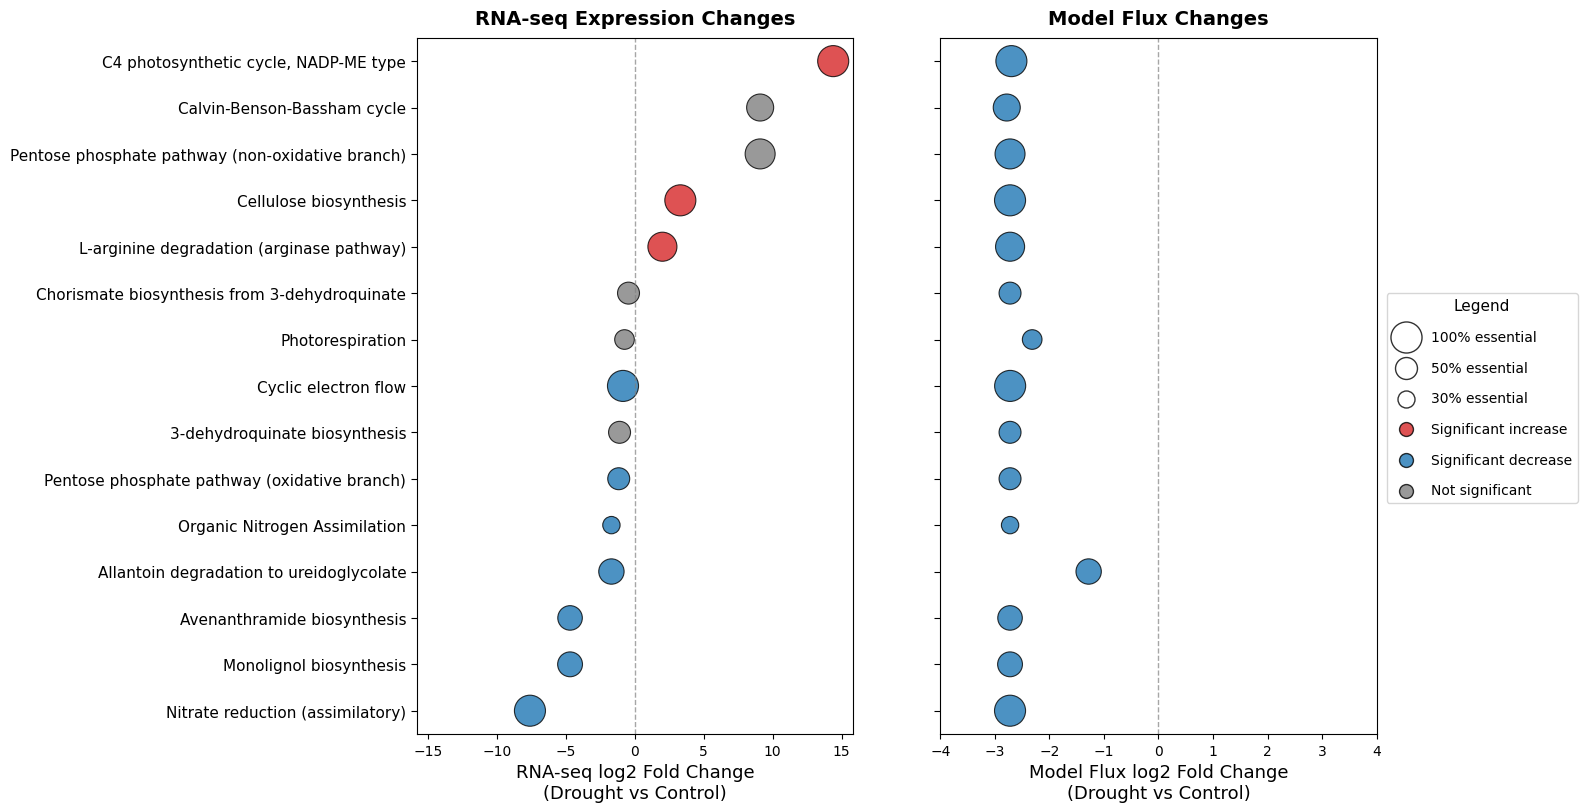


=== Summary Statistics ===
Number of pathways plotted: 15
RNA log2FC range: -7.610 to 14.390
Flux log2FC range: -2.782 to -1.280
% Essential range: 31.2% to 100.0%

Significant RNA-seq changes: 10/15 (66.7%)
Significant Flux changes: 15/15 (100.0%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Load significant pathways from Excel file
#df = pd.read_excel('bubble_plot_pathways.xlsx')
df = pd.read_excel('bubbles_decNeg.xlsx', header=None)  # Read without assuming headers

# Check what we loaded
print("DataFrame shape:", df.shape)
print("First few rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())

# Force assign column names based on expected structure
# Assuming 6 columns in the order you specified
if df.shape[1] == 6:
    df.columns = ['Pathway', '%_Essential', 'RNA_log2FC', 'pvalue_RNA', 'Flux_log2FC', 'pvalue_flux']
else:
    print(f"Warning: Expected 6 columns but got {df.shape[1]}")
    # Try to proceed with what we have
    if df.shape[1] >= 6:
        # Take first 6 columns
        df = df.iloc[:, :6]
        df.columns = ['Pathway', '%_Essential', 'RNA_log2FC', 'pvalue_RNA', 'Flux_log2FC', 'pvalue_flux']
    else:
        raise ValueError(f"Cannot process file with {df.shape[1]} columns. Expected 6 columns.")

# If the first row looks like headers (contains non-numeric values in numeric columns), skip it
first_row = df.iloc[0]
try:
    # Try to convert what should be numeric columns
    pd.to_numeric(first_row['%_Essential'])
    pd.to_numeric(first_row['RNA_log2FC'])
except:
    print("First row appears to be headers, removing it")
    df = df.iloc[1:].reset_index(drop=True)

# Strip whitespace from column names (safety measure)
df.columns = df.columns.str.strip()

# Convert Pathway column to string and strip whitespace
df['Pathway'] = df['Pathway'].astype(str).str.strip()

# Filter out empty or invalid pathways
df = df[df['Pathway'].notna() & (df['Pathway'] != '') & (df['Pathway'] != 'nan')]

# Convert to proper numeric types
numeric_columns = ['%_Essential', 'RNA_log2FC', 'pvalue_RNA', 'Flux_log2FC', 'pvalue_flux']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove any rows with NaN values in critical columns
initial_count = len(df)
df = df.dropna(subset=numeric_columns)
print(f"\nRemoved {initial_count - len(df)} rows with invalid data")

# Check if we have data left
if len(df) == 0:
    raise ValueError("No valid data rows after cleaning. Please check your Excel file format.")

print(f"\nProcessing {len(df)} valid pathways")

# Define significance threshold
significance_threshold = 0.05

# Function to determine bubble color based on significance and direction
def get_bubble_color(log2fc, pvalue):
    if pvalue < significance_threshold:
        if log2fc > 0:
            return '#d62728'  # Red for significant increase
        else:
            return '#1f77b4'  # Blue for significant decrease
    else:
        return '#808080'  # Grey for not significant

# Add color columns for RNA and Flux
df['RNA_color'] = df.apply(lambda row: get_bubble_color(row['RNA_log2FC'], row['pvalue_RNA']), axis=1)
df['Flux_color'] = df.apply(lambda row: get_bubble_color(row['Flux_log2FC'], row['pvalue_flux']), axis=1)

# Sort pathways by RNA-seq log2 Fold Change (descending)
df = df.sort_values('RNA_log2FC', ascending=False).reset_index(drop=True)

# Extract variables
pathways = df['Pathway'].tolist()
growth_percent = df['%_Essential'].values
rna_log2fc = df['RNA_log2FC'].values
flux_log2fc = df['Flux_log2FC'].values
rna_colors = df['RNA_color'].values
flux_colors = df['Flux_color'].values

# Debug print
print(f"\nNumber of pathways: {len(pathways)}")
print(f"First few pathways: {pathways[:3] if len(pathways) > 0 else 'None'}")
print(f"Data ranges:")
print(f"  RNA log2FC: [{rna_log2fc.min():.2f}, {rna_log2fc.max():.2f}]")
print(f"  Flux log2FC: [{flux_log2fc.min():.2f}, {flux_log2fc.max():.2f}]")
print(f"  % Essential: [{growth_percent.min():.1f}, {growth_percent.max():.1f}]")

# Bubble size scaling
bubble_scale = 5
bubble_sizes = growth_percent * bubble_scale

# Create figure with subplots - adjust height based on number of pathways
fig_height = max(8, min(20, len(pathways) * 0.35))  # Dynamic height with max limit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, fig_height))

# RNA-seq plot (left)
y_positions = list(range(len(pathways)))
scatter1 = ax1.scatter(rna_log2fc, y_positions, s=bubble_sizes,
                      c=rna_colors, edgecolor='k', linewidth=0.8, alpha=0.8)

# Model Flux plot (right)
scatter2 = ax2.scatter(flux_log2fc, y_positions, s=bubble_sizes,
                      c=flux_colors, edgecolor='k', linewidth=0.8, alpha=0.8)

# Add vertical dashed lines at x = 0
ax1.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Set up y-axis for both plots
ax1.set_ylim(-0.5, len(pathways) - 0.5)
ax2.set_ylim(-0.5, len(pathways) - 0.5)

# Set y-axis labels (only on left plot)
ax1.set_yticks(y_positions)
ax1.set_yticklabels(pathways, fontsize=11)
ax1.invert_yaxis()

# Right plot - no labels but same ticks
ax2.set_yticks(y_positions)
ax2.set_yticklabels([])
ax2.invert_yaxis()

# Make sure y-axis is visible on left plot
ax1.tick_params(axis='y', which='major', labelsize=11, length=4)
ax2.tick_params(axis='y', which='major', length=4)

# Axis labels
ax1.set_xlabel('RNA-seq log2 Fold Change\n(Drought vs Control)', fontsize=13)
ax2.set_xlabel('Model Flux log2 Fold Change\n(Drought vs Control)', fontsize=13)

# Set x-axis limits to be symmetric around 0
max_rna = max(abs(rna_log2fc.min()), abs(rna_log2fc.max())) * 1.1
max_flux = max(abs(flux_log2fc.min()), abs(flux_log2fc.max())) * 1.1
ax1.set_xlim(-max_rna, max_rna)
ax2.set_xlim(-4, 4)
#ax2.set_xlim(-max_flux, max_flux)  # Now symmetric

# Add titles to subplots
ax1.set_title('RNA-seq Expression Changes', fontsize=14, fontweight='bold', pad=10)
ax2.set_title('Model Flux Changes', fontsize=14, fontweight='bold', pad=10)

# Create legend for bubble size
legend_percents = [100, 50, 30]
legend_sizes = [p * bubble_scale for p in legend_percents]
size_handles = [
    plt.scatter([], [], s=size, c='white', edgecolors='k', alpha=0.8)
    for size in legend_sizes
]
size_labels = [f'{p}% essential' for p in legend_percents]  # Shortened labels

# Create legend for colors
color_handles = [
    plt.scatter([], [], s=100, c='#d62728', edgecolors='k', alpha=0.8),  # Red
    plt.scatter([], [], s=100, c='#1f77b4', edgecolors='k', alpha=0.8),  # Blue
    plt.scatter([], [], s=100, c='#808080', edgecolors='k', alpha=0.8)   # Grey
]
color_labels = ['Significant increase', 'Significant decrease', 'Not significant']

# Combine handles and labels
all_handles = size_handles + color_handles
all_labels = size_labels + color_labels

# Add legend to the right
legend = fig.legend(
    all_handles, all_labels,
    scatterpoints=1,
    frameon=True,
    fontsize=10,
    loc='center right',
    bbox_to_anchor=(0.98, 0.5),
    title='Legend',
    title_fontsize=11,
    labelspacing=1.2,
    handletextpad=0.8,
    borderaxespad=0.5
)

# Adjust layout - don't use tight_layout with subplots_adjust
plt.subplots_adjust(left=0.25, right=0.85, top=0.95, bottom=0.08)

# Save figure
plt.savefig("dual_bubble_plot_pathways.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\n=== Summary Statistics ===")
print(f"Number of pathways plotted: {len(df)}")
print(f"RNA log2FC range: {rna_log2fc.min():.3f} to {rna_log2fc.max():.3f}")
print(f"Flux log2FC range: {flux_log2fc.min():.3f} to {flux_log2fc.max():.3f}")
print(f"% Essential range: {growth_percent.min():.1f}% to {growth_percent.max():.1f}%")

# Print significance summary
rna_sig = sum(df['pvalue_RNA'] < significance_threshold)
flux_sig = sum(df['pvalue_flux'] < significance_threshold)
print(f"\nSignificant RNA-seq changes: {rna_sig}/{len(df)} ({100*rna_sig/len(df):.1f}%)")
print(f"Significant Flux changes: {flux_sig}/{len(df)} ({100*flux_sig/len(df):.1f}%)")